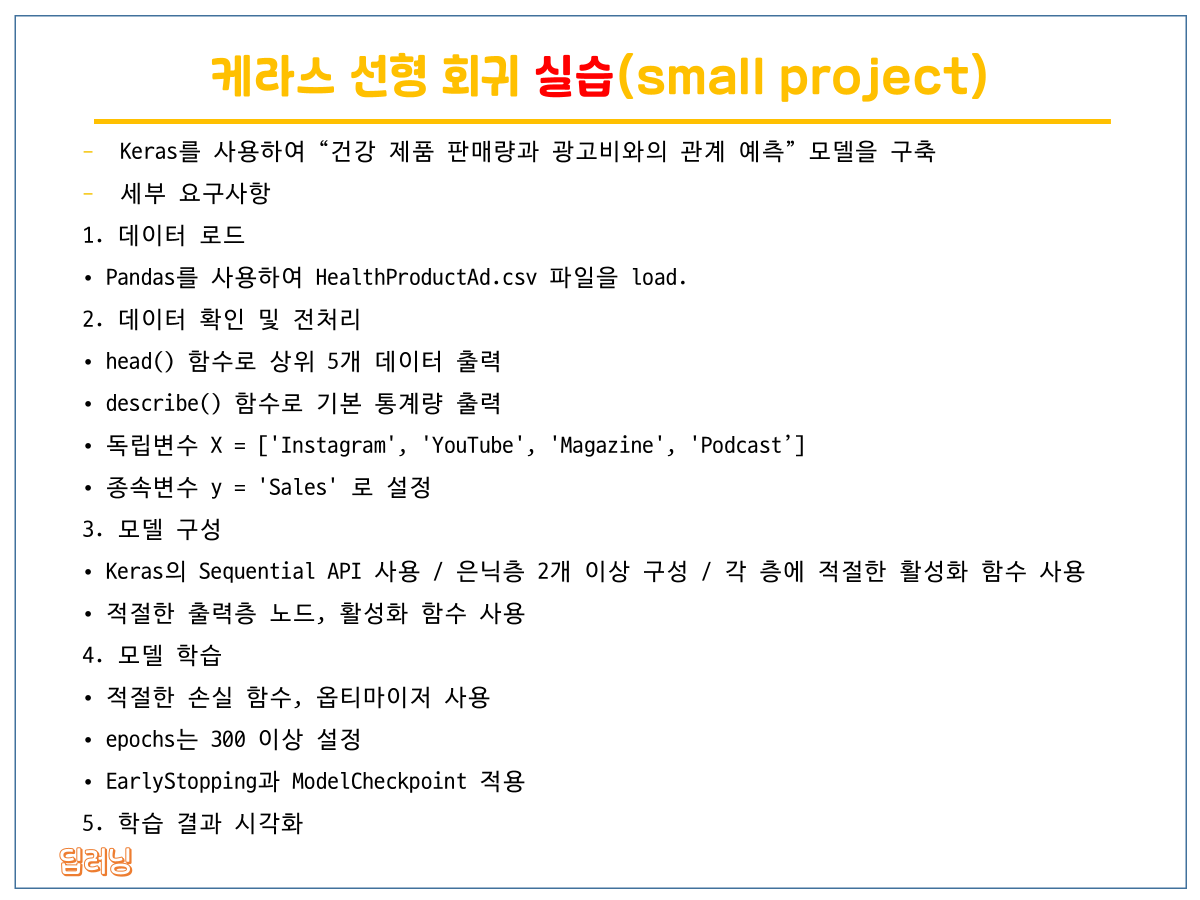

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# seed 값 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

df = pd.read_csv("dataset/HealthProductAd.csv", sep=",")

print(df.head())
print(df.describe())

   Instagram  YouTube  Magazine  Podcast  Sales
0      143.6     14.4      33.9      1.6  12.07
1      287.7     99.1       8.8     15.9  23.73
2      233.0     54.0      12.3     16.2  18.84
3      199.7     81.2      45.4     19.1  18.56
4       89.0    137.1      32.3     21.8  18.56
        Instagram     YouTube    Magazine     Podcast       Sales
count  100.000000  100.000000  100.000000  100.000000  100.000000
mean   167.546000   79.694000   28.292000   14.736000   16.710600
std     74.373555   41.035335   13.204068    8.802714    4.994331
min     51.400000   11.000000    5.200000    0.400000    1.490000
25%     98.300000   43.900000   17.425000    7.475000   13.047500
50%    166.050000   80.800000   30.350000   15.300000   17.435000
75%    232.550000  117.250000   38.850000   22.100000   19.765000
max    296.700000  148.000000   49.600000   29.700000   28.580000


In [9]:
dataset = df.values
X = dataset[:, 0:4]
Y = dataset[:, 4]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

mean = X_train.mean(axis=0)
X_train -= mean
std = X_train.std(axis=0)
X_train /= std

In [ ]:
model = Sequential()
model.add(Input(shape=(4,)))  
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# 자동 중단
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 자동 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=50)

# 모델 저장 조건 설정
modelpath = "./model/HealthProductAd_1002.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)

history = model.fit(X_train, Y_train, validation_split=0.33, epochs=500, batch_size=10, callbacks=[early_stopping_callback, checkpointer])

hist = pd.DataFrame(history.history)
print(hist.tail())

# 검증 데이터의 손실 저장
y_vloss = history.history['val_loss']

# 학습 데이터의 손실 저장
y_loss = history.history['loss']

Epoch 1/500
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 219.1299
Epoch 1: val_loss improved from None to 321.37354, saving model to ./model/HealthProductAd_1002.keras

Epoch 1: finished saving model to ./model/HealthProductAd_1002.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - loss: 265.4457 - val_loss: 321.3735
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 202.1326
Epoch 2: val_loss improved from 321.37354 to 318.74377, saving model to ./model/HealthProductAd_1002.keras

Epoch 2: finished saving model to ./model/HealthProductAd_1002.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 263.1043 - val_loss: 318.7438
Epoch 3/500
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 256.0604 
Epoch 3: val_loss improved from 318.74377 to 315.81204, saving model to ./model/HealthProductAd_1002.keras

Epoch 3: finished saving model to ./model/HealthProductAd_1002.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 260.6054 - val_loss: 315.8120
Epoch 4/500
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18

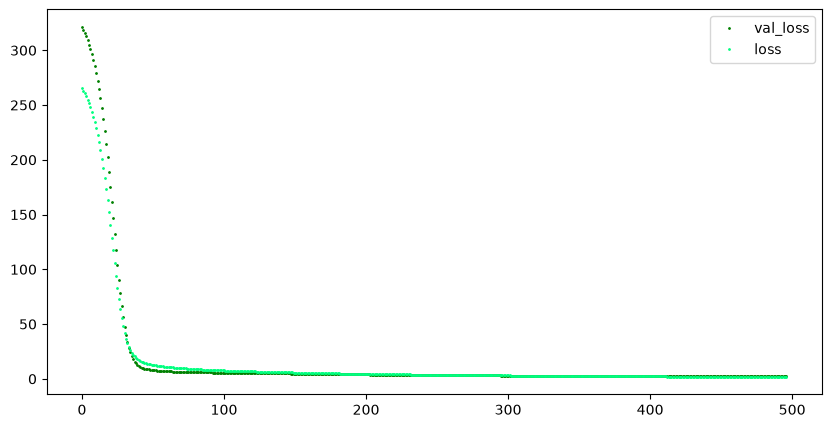

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
실제 판매량: 15.94, 예상 판매량: 808.37
실제 판매량: 19.76, 예상 판매량: 1236.48
실제 판매량: 18.84, 예상 판매량: 987.62
실제 판매량: 18.24, 예상 판매량: 1121.73
실제 판매량: 14.71, 예상 판매량: 924.44
실제 판매량: 19.39, 예상 판매량: 1009.51
실제 판매량: 17.53, 예상 판매량: 877.51
실제 판매량: 22.60, 예상 판매량: 1034.97
실제 판매량: 22.54, 예상 판매량: 1203.72
실제 판매량: 17.22, 예상 판매량: 813.75


In [11]:
# 에포크별 학습 손실과 검증 손실 표시
x_len = np.arange(len(y_loss))
plt.figure(figsize=(10, 5))
plt.plot(x_len, y_vloss, "o", c="green", markersize=1, label='val_loss')
plt.plot(x_len, y_loss, "o", c="springgreen", markersize=1, label='loss')

plt.legend()
plt.show()

# 예측 값과 실제 값의 비교
Y_prediction = model.predict(X_test).flatten()

for i in range(10):
    label = Y_test[i]
    prediction = Y_prediction[i]
    print("실제 판매량: {:.2f}, 예상 판매량: {:.2f}".format(label, prediction))